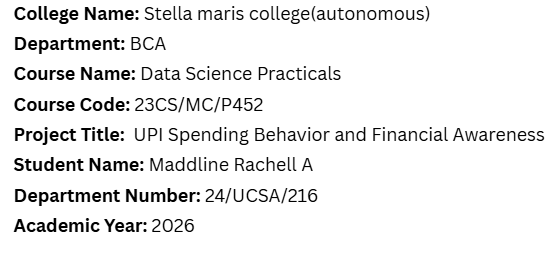

<h2>2.Problem Statement:</h2>
<p>The increasing use of UPI has made digital payments quick and convenient for people, but it may also affect how people manage their money and keep tabs on their spending behaviour. Sometimes users may run out of balance unexpectedly that may lead them to borrow money or delay their payments. The aim of this project is to analyze UPI usage patterns and financial habits.</p>

<h2>3.Objectives:</h2>
<p><b>i)</b> To understand the UPI usage pattern.</p>
<p><b>ii)</b> To clean and process the collected data.</p>
<p><b>iii)</b> To analyze the data.</p>
<p><b>iv)</b> To visualize the data.</p>
<p><b>v)</b> To identify the right feature for the training model.</p>
<p><b>vi)</b> To build the logistic regression model.</p>
<p><b>vii)</b> To evaluate the model performance.</p>
<p><b>viii)</b> To predict the new person's financial behaviour.</p>

<h2>4.Dataset Description</h2>
<p>The dataset used in the analysis was collected through a survey on "upi usage and financial habits".</p>
<p>The dataset contains the info about individual UPI transaction patterns , spending budgets and budgeting habits they have.</p>
<p>Main aim is to analyse if the collected factors are related to a person ending up borrowing money or delaying their payment.</p>
<p><b>Number of records:</b> 101 survey responses (100 after removing one response with no answer for the target)</p>
<p><b>Number of attributes:</b> 12 (selected from the 15 survey questions)</p>
<p><b>Target Variable:</b> BorrowedMoney</p>
<p><b>Privacy:</b> respondent names and timestamps were removed from the shared dataset.</p>

<h2>5.Software and Libraries Used</h2>

The following software and Python libraries were used to perform data cleaning, analysis, visualization, and machine learning in this project.

<h4>Software</h4>
<p><b>Jupyter Notebook –</b> Used to write and execute Python code and document the complete data science process.</p>
<p><b>Python –</b> Used as the main programming language for data processing, analysis, visualization, and model building.</p>

<h4>Libraries:</h4>
<p>1.Pandas</p>
<p>2.Matplotlib</p>
<p>3.scikit-learn</p>

<h2>6.Dataset exploration:</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

<h3>Interpretation:</h3>

<p>Python libraries are imported in this cell.
Pandas for data handling, matplotlib for data visualisation,and Scikit-learn is used for splitting the data, building the Logistic Regression model, and evaluating its performance.</p>

In [2]:
df = pd.read_csv('upi.csv')
df.head()

,Q2. Age,Q3. Gender,Q4. Current occupation,Q5. Monthly income or allowance,Q6. How many UPI transactions do you make in a typical week?,Q7. What is your average UPI transaction amount?,Q8. Do you check your account balance before making a UPI payment?,Q9. How much time do you spend deciding before confirming a UPI payment?,Q10. Do you track your monthly expenses in any way?,Q11. Do you set a monthly spending budget for yourself?,"Q12. In the past 3 months, has your UPI balance been lower than you expected when you tried to make a payment?",Q13. Have you ever borrowed money or delayed a payment because you ran out of balance unexpectedly?,"Q14. On a scale of 1–5, how financially aware/careful do you consider yourself?",Q15. Do you think UPI's ease of use makes people spend more than they intend to?
0,19.0,Female,student,under 5000,0-2,100-500,1.0,I actively pause and consider,"I track mentally, no records",No,never,No,3.0,5.0
1,19.0,Female,student,under 5000,3-6,under 100,4.0,A few seconds of thought,"I track mentally, no records",Yes,once or twice,No,4.0,5.0
2,19.0,Female,student,"Above 40,000",NaN,"1,000-5,000",1.0,I actively pause and consider,"No, I don't track",No,frequently,Yes,1.0,5.0
3,17.0,Male,student,under 5000,7-15,100-500,2.0,A few seconds of thought,"I track mentally, no records",sometimes,frequently,Yes,2.0,4.0
4,22.0,Female,working professional,under 5000,3-6,100-500,5.0,I actively pause and consider,"I track mentally, no records",sometimes,once or twice,No,5.0,5.0


In [3]:
df.tail()

,Q2. Age,Q3. Gender,Q4. Current occupation,Q5. Monthly income or allowance,Q6. How many UPI transactions do you make in a typical week?,Q7. What is your average UPI transaction amount?,Q8. Do you check your account balance before making a UPI payment?,Q9. How much time do you spend deciding before confirming a UPI payment?,Q10. Do you track your monthly expenses in any way?,Q11. Do you set a monthly spending budget for yourself?,"Q12. In the past 3 months, has your UPI balance been lower than you expected when you tried to make a payment?",Q13. Have you ever borrowed money or delayed a payment because you ran out of balance unexpectedly?,"Q14. On a scale of 1–5, how financially aware/careful do you consider yourself?",Q15. Do you think UPI's ease of use makes people spend more than they intend to?
96,26.0,Male,working professional,"Above 40,000",morethan 15,"1,000-5,000",2.0,A few seconds of thought,"No, I don't track",No,never,No,5.0,3.0
97,16.0,Female,student,under 5000,3-6,100-500,4.0,A few seconds of thought,"I track mentally, no records",sometimes,once or twice,No,4.0,3.0
98,45.0,Male,working professional,under 5000,0-2,under 100,3.0,I pay instantly without thinking.,"I track mentally, no records",No,never,No,3.0,3.0
99,21.0,Male,working professional,"Above 40,000",morethan 15,"1,000-5,000",1.0,I pay instantly without thinking.,"No, I don't track",No,never,No,5.0,5.0
100,34.0,Female,self-employed,"Above 40,000",3-6,"500-1,000",5.0,I pay instantly without thinking.,"I track mentally, no records",No,never,No,5.0,3.0


In [4]:
df.dtypes

  Q2. Age                                                                                                             float64
  Q3. Gender                                                                                                              str
  Q4. Current occupation                                                                                                  str
  Q5. Monthly income or allowance                                                                                         str
Q6. How many UPI transactions do you make in a typical week?                                                              str
  Q7. What is your average UPI transaction amount?                                                                        str
  Q8. Do you check your account balance before making a UPI payment?                                                  float64
  Q9. How much time do you spend deciding before confirming a UPI payment?                                            

In [5]:
print("Rows:", df.shape[0]) #0 is for rows
print("Columns:", df.shape[1]) #1 is for columns

Rows: 101
Columns: 14


<h3>Interpretation:</h3>
<p>The number of columns and rows in the data frame are found.</p>

In [6]:
df.columns

Index(['  Q2. Age  ', '  Q3. Gender  ', '  Q4. Current occupation  ',
       '  Q5. Monthly income or allowance  ',
       'Q6. How many UPI transactions do you make in a typical week?',
       '  Q7. What is your average UPI transaction amount?  ',
       '  Q8. Do you check your account balance before making a UPI payment?  ',
       '  Q9. How much time do you spend deciding before confirming a UPI payment?  ',
       '  Q10. Do you track your monthly expenses in any way?  ',
       '  Q11. Do you set a monthly spending budget for yourself?  ',
       '  Q12. In the past 3 months, has your UPI balance been lower than you expected when you tried to make a payment?  ',
       '  Q13. Have you ever borrowed money or delayed a payment because you ran out of balance unexpectedly?  ',
       '  Q14. On a scale of 1–5, how financially aware/careful do you consider yourself?  ',
       '  Q15. Do you think UPI's ease of use makes people spend more than they intend to?  '],
      dtype='str'

<h3>Interpretation:</h3>
<p>Names of the columns.</p>

In [7]:
df.columns = [c.strip() for c in df.columns]
#in order to remove the spaces

<h3>Interpretation:</h3>
<p>To strip the empty spaces.</p>

In [8]:
df = df.rename(columns={
    'Q2. Age': 'Age',
    'Q3. Gender': 'Gender',
    'Q4. Current occupation': 'Occupation',
    'Q5. Monthly income or allowance': 'Income',
    'Q6. How many UPI transactions do you make in a typical week?': 'WeeklyTxns',
    'Q7. What is your average UPI transaction amount?': 'AvgAmount',
    'Q8. Do you check your account balance before making a UPI payment?': 'ChecksBalance',
    'Q10. Do you track your monthly expenses in any way?': 'TracksExpenses',
    'Q11. Do you set a monthly spending budget for yourself?': 'SetsBudget',
    'Q12. In the past 3 months, has your UPI balance been lower than you expected when you tried to make a payment?': 'BalanceSurprise',
    'Q13. Have you ever borrowed money or delayed a payment because you ran out of balance unexpectedly?': 'BorrowedMoney',
    'Q14. On a scale of 1–5, how financially aware/careful do you consider yourself?': 'AwarenessScore',
})

# only the columns i need
df = df[['Age', 'Gender', 'Occupation', 'Income', 'WeeklyTxns', 'AvgAmount',
         'ChecksBalance', 'TracksExpenses', 'SetsBudget', 'BalanceSurprise',
         'AwarenessScore', 'BorrowedMoney']]

df.head()


,Age,Gender,Occupation,Income,WeeklyTxns,AvgAmount,ChecksBalance,TracksExpenses,SetsBudget,BalanceSurprise,AwarenessScore,BorrowedMoney
0,19.0,Female,student,under 5000,0-2,100-500,1.0,"I track mentally, no records",No,never,3.0,No
1,19.0,Female,student,under 5000,3-6,under 100,4.0,"I track mentally, no records",Yes,once or twice,4.0,No
2,19.0,Female,student,"Above 40,000",NaN,"1,000-5,000",1.0,"No, I don't track",No,frequently,1.0,Yes
3,17.0,Male,student,under 5000,7-15,100-500,2.0,"I track mentally, no records",sometimes,frequently,2.0,Yes
4,22.0,Female,working professional,under 5000,3-6,100-500,5.0,"I track mentally, no records",sometimes,once or twice,5.0,No


<h3>Interpretation:</h3>
<p>Columns are renamed to short names, and only the 12 columns needed for the analysis are kept (this also drops the name and timestamp columns).</p>

In [9]:
df.isnull().sum()

Age                1
Gender             0
Occupation         1
Income             1
WeeklyTxns         1
AvgAmount          2
ChecksBalance      1
TracksExpenses     0
SetsBudget         0
BalanceSurprise    0
AwarenessScore     1
BorrowedMoney      1
dtype: int64

<h3>Interpretation:</h3>
<p>This cell identifies missing values in each column. Missing values need to be handled before analysis and machine learning.</p>

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


<h3>Interpretation:</h3>
<p>This cell checks whether duplicate records are present in the dataset. Removing duplicates helps prevent repeated observations from affecting the analysis and model.</p>

<h2>7.Data Cleaning:</h2>
<p>-Dropping the null values in the target</p>
<p>-Mode finds the most frequently occured valued in each column and replace NA with that value</p>


In [11]:
df = df.dropna(subset=["BorrowedMoney"])
df = df.fillna(df.mode().iloc[0])
print(df.isnull().sum())

Age                0
Gender             0
Occupation         0
Income             0
WeeklyTxns         0
AvgAmount          0
ChecksBalance      0
TracksExpenses     0
SetsBudget         0
BalanceSurprise    0
AwarenessScore     0
BorrowedMoney      0
dtype: int64


<h3>Interpretation:</h3>
<p>Some answers for BorrowedMoney were missing, so those rows were removed. For the other missing answers, we used the most common answer to fill them in.
</p>

In [12]:
df['BorrowedMoney_num'] = df['BorrowedMoney'].map({'No': 0, 'Yes': 1})

df['BalanceSurprise_num'] = df['BalanceSurprise'].map({
    'never': 0, 'once or twice': 1, 'a few times': 2, 'frequently': 3
})

df['SetsBudget_num'] = df['SetsBudget'].map({'No': 0, 'sometimes': 1, 'Yes': 2})

df['WeeklyTxns_num'] = df['WeeklyTxns'].map({
    '0-2': 0, '3-6': 1, '7-15': 2, 'morethan 15': 3
})

df[['BorrowedMoney', 'BorrowedMoney_num', 'BalanceSurprise', 'BalanceSurprise_num']].head()

,BorrowedMoney,BorrowedMoney_num,BalanceSurprise,BalanceSurprise_num
0,No,0,never,0
1,No,0,once or twice,1
2,Yes,1,frequently,3
3,Yes,1,frequently,3
4,No,0,once or twice,1


<h3>Interpretation:</h3>
<p>The categorical variables are converted into numerical values so that they can be used for correlation analysis and machine learning.</p>

<h2>8.Statistical Analysis</h2>

In [13]:
df.describe()

,Age,ChecksBalance,AwarenessScore,BorrowedMoney_num,BalanceSurprise_num,SetsBudget_num,WeeklyTxns_num
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,27.770000,3.050000,3.570000,0.300000,1.010000,0.950000,1.490000
std,11.343004,1.358661,1.007597,0.460566,0.989796,0.808728,1.087068
min,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,3.000000,0.000000,0.000000,0.000000,1.000000
50%,23.000000,3.000000,4.000000,0.000000,1.000000,1.000000,2.000000
75%,30.250000,4.000000,4.000000,1.000000,2.000000,2.000000,2.000000
max,55.000000,5.000000,5.000000,1.000000,3.000000,2.000000,3.000000


<h3>Interpretation:</h3>
<p>The describe() function provides important descriptive statistics such as count, mean, standard deviation, minimum, maximum, and quartile values. These statistics help understand the distribution of the numerical variables.</p>

In [14]:
print("Mean:")
print(df[["Age", "ChecksBalance", "AwarenessScore"]].mean())

Mean:
Age               27.77
ChecksBalance      3.05
AwarenessScore     3.57
dtype: float64


<h3>Interpretation:</h3>
<p>The mean represents the average value of each selected numerical variable.</p>

In [15]:
print("Median:")
print(df[["Age", "ChecksBalance", "AwarenessScore"]].median())

Median:
Age               23.0
ChecksBalance      3.0
AwarenessScore     4.0
dtype: float64


<h3>Interpretation:</h3>
<p>The median is the middle value when all the values are arranged in order.</p>

In [16]:
print("Mode:")
print(df[["Age", "ChecksBalance", "AwarenessScore"]].mode().iloc[0])

Mode:
Age               19.0
ChecksBalance      3.0
AwarenessScore     3.0
Name: 0, dtype: float64


<h3>Interpretation:</h3>
<p>The mode represents the most frequently occurring value in each selected variable.</p>

In [17]:
print("Variance:")
print(df[["Age", "ChecksBalance", "AwarenessScore"]].var())

Variance:
Age               128.663737
ChecksBalance       1.845960
AwarenessScore      1.015253
dtype: float64


<h3>Interpretation:</h3>
<p>Variance measures how much the values differ from their average. A higher variance indicates greater variation among the respondents, while a lower variance indicates that the values are closer to the mean.</p>

In [18]:
print("Standard Deviation:")
print(df[["Age", "ChecksBalance", "AwarenessScore"]].std())

Standard Deviation:
Age               11.343004
ChecksBalance      1.358661
AwarenessScore     1.007597
dtype: float64


<h3>Interpretation:</h3>
<p>Standard deviation shows the amount of variation in the data around the mean. It helps understand how consistently the respondents' values are distributed.</p>

In [19]:
print(df[[
    "Age",
    "ChecksBalance",
    "AwarenessScore",
    "BalanceSurprise_num",
    "SetsBudget_num",
    "WeeklyTxns_num"
]].corr())

                          Age  ChecksBalance  AwarenessScore  \
Age                  1.000000       0.103656       -0.010508   
ChecksBalance        0.103656       1.000000        0.185569   
AwarenessScore      -0.010508       0.185569        1.000000   
BalanceSurprise_num -0.275097       0.074736       -0.329875   
SetsBudget_num       0.074711       0.085034        0.221265   
WeeklyTxns_num       0.095246      -0.126181        0.046755   

                     BalanceSurprise_num  SetsBudget_num  WeeklyTxns_num  
Age                            -0.275097        0.074711        0.095246  
ChecksBalance                   0.074736        0.085034       -0.126181  
AwarenessScore                 -0.329875        0.221265        0.046755  
BalanceSurprise_num             1.000000       -0.075082        0.126829  
SetsBudget_num                 -0.075082        1.000000        0.062618  
WeeklyTxns_num                  0.126829        0.062618        1.000000  


<h3>Interpretation:</h3>
<p>The table helps us see how the different answers are connected. Most of them do not have a strong connection with each other.</p>

<h5>Negative correlation:</h5><p>one goes up, the other tends to go down.</p>
<h5>Positive correlation:</h5><p>both tend to go up or down together.
</p>

In [20]:
df['BorrowedMoney'].value_counts()

BorrowedMoney
No     70
Yes    30
Name: count, dtype: int64

<h3>Interpretation:</h3>
<p>Count of each answer in the BorrowedMoney column: 70 respondents said No and 30 said Yes.</p>

<h2>9.Data Visualization</h2>

<h4>Histogram</h4>

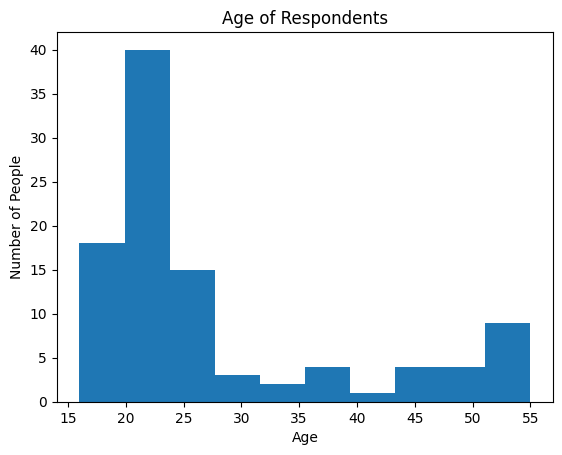

In [21]:
plt.hist(df['Age'], bins=10)
plt.title('Age of Respondents')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.show()

<h3>Interpretation:</h3>
<p>The histogram shows the distribution of respondents across different age groups. It helps identify the age range in which most respondents are concentrated.</p>

<h4>Bar Graph</h4>

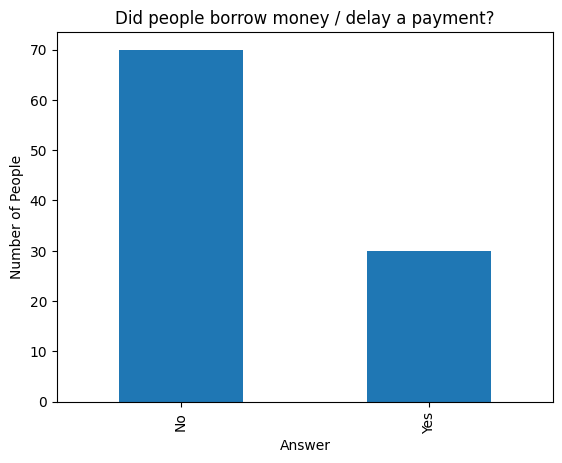

In [22]:
df['BorrowedMoney'].value_counts().plot(kind='bar')
plt.title('Did people borrow money / delay a payment?')
plt.xlabel('Answer')
plt.ylabel('Number of People')
plt.show()

<h3>Interpretation:</h3>
<p>The bar chart shows the number of respondents who reported borrowing money or delaying a payment and those who did not. The dataset contains more respondents in the "No" category than the "Yes" category.</p>

<h4>Crosstab</h4>

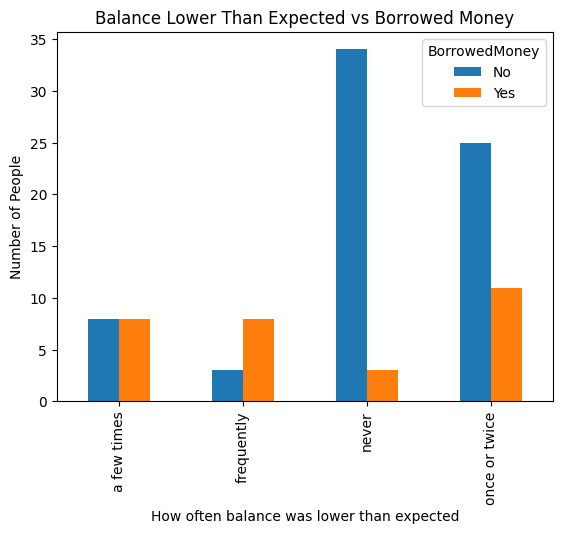

In [23]:
pd.crosstab(df['BalanceSurprise'], df['BorrowedMoney']).plot(kind='bar')
plt.title('Balance Lower Than Expected vs Borrowed Money')
plt.xlabel('How often balance was lower than expected')
plt.ylabel('Number of People')
plt.show()

<h3>Interpretation:</h3>
<p>This chart compares how often respondents found their balance lower than expected with whether they borrowed money or delayed a payment. It helps identify whether unexpected lower balances are associated with the target behaviour. Respondents who never had a lower balance rarely borrowed or delayed a payment (3 of 37), while 8 of 11 who frequently did had borrowed or delayed.</p>
<p>crosstab is used here to compare between two values that is yes or no.</p>

<h4>Boxplot</h4>

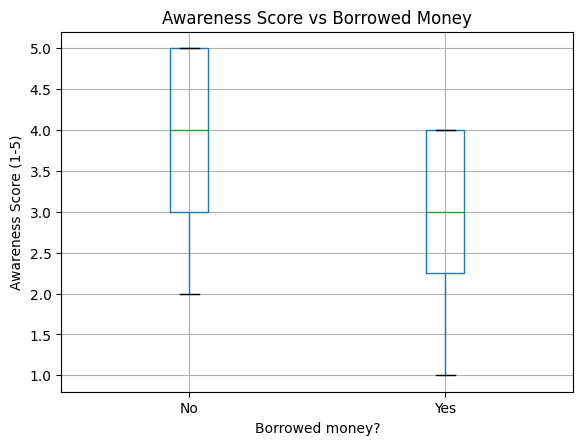

In [24]:
df.boxplot(column='AwarenessScore', by='BorrowedMoney')
plt.title('Awareness Score vs Borrowed Money')
plt.suptitle('')
plt.xlabel('Borrowed money?')
plt.ylabel('Awareness Score (1-5)')
plt.show()

<h3>Interpretation</h3>
<p>The boxplot compares awareness scores between respondents who borrowed money or delayed payments and those who did not. It shows the distribution, median, and variation of awareness scores for the two groups. Respondents who borrowed or delayed a payment rated themselves as less financially aware (average about 3.0 vs 3.8).</p>

<h4>Bar graph</h4>

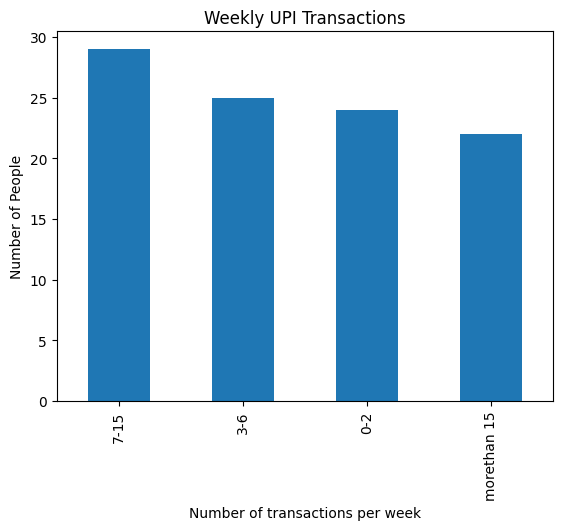

In [25]:
df['WeeklyTxns'].value_counts().plot(kind='bar')
plt.title('Weekly UPI Transactions')
plt.xlabel('Number of transactions per week')
plt.ylabel('Number of People')
plt.show()

<h3>Interpretation:</h3>
<p>The bar chart shows the distribution of respondents according to their weekly UPI transaction frequency. It helps identify the most common transaction-frequency category among the respondents.</p>

<h2>10.Model Building</h2>

In [26]:
X = df[['ChecksBalance', 'AwarenessScore', 'BalanceSurprise_num', 'SetsBudget_num', 'WeeklyTxns_num']]
y = df['BorrowedMoney_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<h3>Interpretation:</h3>
<p>The selected features are used as input variables for prediction, while BorrowedMoney_num is selected as the target variable.</p>
<p>The dataset is divided into training and testing sets. 75% of the data is used to train the model and the remaining 25% is used to test its performance on unseen data.</p>

In [27]:
model = LogisticRegression()

model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, train_predictions) * 100, "%") #multiplied by 100 inorder to make it print as a percntage
print("Testing Accuracy:", accuracy_score(y_test, test_predictions) * 100, "%")

Training Accuracy: 80.0 %
Testing Accuracy: 80.0 %


<h3>Interpretation:</h3>
<p>A Logistic Regression model is created and trained using the training dataset.</p>
<p>The trained model is used to predict the target values for both the training and testing datasets.</p>
<p>The model achieved 80% accuracy on both the training and testing datasets.</p>

In [28]:
print("Always predicting 'No' - test set:", round((y_test == 0).mean() * 100, 1), "%")
print("Always predicting 'No' - full data:", round((y == 0).mean() * 100, 1), "%")

Always predicting 'No' - test set: 64.0 %
Always predicting 'No' - full data: 70.0 %


<h3>Interpretation:</h3>
<p>This is the baseline: the accuracy we would get without any model, just by always guessing the most common answer ("No"). The model's 80% test accuracy is better than this baseline, but the test set is small (25 people), so the gap should be read with care.</p>

In [29]:
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(coef.round(2))

AwarenessScore        -0.96
ChecksBalance         -0.09
SetsBudget_num         0.10
WeeklyTxns_num         0.35
BalanceSurprise_num    0.84
dtype: float64


<h3>Interpretation:</h3>
<p>The coefficients show how each feature pushes the prediction. A positive value increases the chance of borrowing or delaying a payment and a negative value decreases it. BalanceSurprise_num (positive) and AwarenessScore (negative) have the largest effect, while ChecksBalance and SetsBudget are close to zero, which matches the charts above. These features are on different scales, so this is only a rough comparison.</p>

In [30]:
print(confusion_matrix(y_test, test_predictions))

[[15  1]
 [ 4  5]]


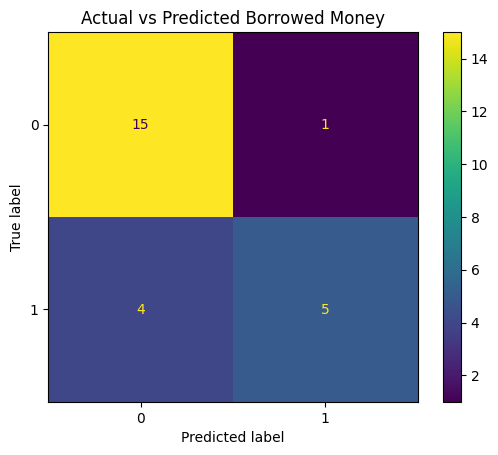

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_predictions)

plt.title("Actual vs Predicted Borrowed Money")
plt.show()

<h3>Interpretation:</h3>
<p>The test set has only 25 people, so every single mistake moves the accuracy by 4 percentage points.</p>
<p>15 → The model correctly predicted No for 15 people.</p>
<p>1 → The person actually said No, but the model predicted Yes.</p>
<p>4 → The person actually said Yes, but the model predicted No.</p>
<p>5 → The model correctly predicted Yes for 5 people.</p>

In [32]:
print(classification_report(y_test, test_predictions))

              precision    recall  f1-score   support

           0       0.79      0.94      0.86        16
           1       0.83      0.56      0.67         9

    accuracy                           0.80        25
   macro avg       0.81      0.75      0.76        25
weighted avg       0.81      0.80      0.79        25



<h3>Interpretation:</h3>
<p>For the "No" category, the recall is 0.94, meaning the model correctly identifies most respondents who did not borrow money or delay a payment. For the "Yes" category, the recall is 0.56, showing that the model has more difficulty identifying all respondents who actually borrowed money or delayed a payment. When the model does predict "Yes", it is usually right (precision 0.83), but it misses almost half of the real "Yes" cases.</p>

<h2>11.Prediction for a New Person</h2>

In [33]:
new_person =pd.DataFrame([[1,3,2,1,2]], columns=["ChecksBalance","AwarenessScore","BalanceSurprise_num","SetsBudget_num","WeeklyTxns_num"])

result = model.predict(new_person)

if result[0] == 1:
    print("Prediction: Yes, the person may borrow money or delay a payment.")
else:
    print("Prediction: No, the person may not borrow money or delay a payment.")

Prediction: Yes, the person may borrow money or delay a payment.


<h3>Interpretation:</h3>
<p>The input values are, in order: ChecksBalance = 1 (on the survey's 1-5 scale), AwarenessScore = 3, BalanceSurprise = 2 (a few times), SetsBudget = 1 (sometimes), WeeklyTxns = 2 (7-15 per week). The trained model uses these to predict whether this new person may borrow money or delay a payment.</p>

<h2>12.Findings of the Project</h2>

<p>1.Out of 100 respondents, 70 had not borrowed money or delayed a payment because of low balance, and 30 had.</p>
<p>2.How often the balance was lower than expected was the strongest pattern: only 3 of 37 people who never faced this had borrowed or delayed a payment, compared with 8 of 11 who faced it frequently.</p>
<p>3.Respondents who borrowed or delayed a payment rated themselves as less financially aware (average score about 3.0 vs 3.8).</p>
<p>4.Setting a budget showed only a small difference (23% of budget-setters vs 34% of non-setters had borrowed or delayed), and checking the balance before paying showed almost no difference in this dataset.</p>
<p>5.The logistic regression model reached 80% accuracy on both the training and testing data, compared with 64% if it always predicted "No" on the same test set.</p>
<p>6.The model was better at identifying people who would not have a problem (recall 0.94) than people who would (recall 0.56).</p>
<p>7.With only 100 responses (25 in the test set), these results are exploratory and should not be generalised.</p>

<h2>13.Conclusion</h2>

<p>This project analysed the UPI usage and financial habits of 100 survey respondents. People who often found their balance lower than expected were much more likely to have borrowed money or delayed a payment, and people with higher self-rated financial awareness were less likely to.</p>
<p>Habits like checking the balance and setting a budget showed only a weak relationship in this small sample, so more data would be needed to say whether they really help. A basic logistic regression model could predict the outcome with 80% accuracy, but it misses many of the people who actually run into problems.</p>

<h2>14.Future Scope</h2>

<p>1.Larger data set collection in the future could improve the accuracy</p>
<p>2.More features about spending habits and savings can be added to understand people's financial behaviour furthermore.</p>
<p>3.An application dedicated for this could let people know if their spending behaviour would affect their unexpectedly money running out</p>
<p>4.Use cross-validation and try other models (decision tree, random forest) to get a more reliable estimate than a single 25-person test set.</p>

<h2>15.References</h2>

<p>-Dataset source: upi.csv</p>
<p>-Practical exercises, google searches, AI references, Classroom notes.</p>